# SFMTA Parking Citations Analysis
**Date Range:** January 1, 2016 – Febuary 4, 2026  
This notebook imports, explores, cleans, and visualizes the SFMTA parking citations dataset.

## 1. Install & Import Dependencies

In [2]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn folium geopandas missingno

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


## 2. Load the Dataset
Update the `FILE_PATH` variable below to point to your local SFMTA CSV file. 

In [4]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
FILE_PATH = r'C:\Users\jimmy\Desktop\CS122\ZeninClan-sf-parking-citation-analysis\data\SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv'
DATE_COL  = 'Citation Issued DateTime'
LAT_COL   = 'Latitude'
LON_COL   = 'Longitude'
# ─────────────────────────────────────────────────────────────────────────────

print(f'Loading dataset from: {FILE_PATH}')

df = pd.read_csv(
    FILE_PATH,
    low_memory=False,
    parse_dates=[DATE_COL]
)
print(f'✅ Loaded {len(df):,} rows and {df.shape[1]} columns.')
# takes ~10 mins to filter the data

Loading dataset from: C:\Users\jimmy\Desktop\CS122\ZeninClan-sf-parking-citation-analysis\data\SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv
✅ Loaded 12,303,688 rows and 14 columns.


## 3. Dataset Exploration

In [5]:
# Print shape
print(f'Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns\n')

# Column name overview
print('=== Columns & Data Types ===')
print(df.dtypes.to_string())

Shape: 12,303,688 rows  ×  14 columns

=== Columns & Data Types ===
Citation Number                        str
Citation Issued DateTime    datetime64[us]
Violation                              str
Violation Description                  str
Citation Location                      str
Vehicle Plate State                    str
Vehicle Plate                          str
Fine Amount                            str
Date Added                             str
geom                                   str
supervisor_district                float64
analysis_neighborhood                  str
Latitude                               str
Longitude                              str


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12303688 entries, 0 to 12303687
Data columns (total 14 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Citation Number           str           
 1   Citation Issued DateTime  datetime64[us]
 2   Violation                 str           
 3   Violation Description     str           
 4   Citation Location         str           
 5   Vehicle Plate State       str           
 6   Vehicle Plate             str           
 7   Fine Amount               str           
 8   Date Added                str           
 9   geom                      str           
 10  supervisor_district       float64       
 11  analysis_neighborhood     str           
 12  Latitude                  str           
 13  Longitude                 str           
dtypes: datetime64[us](1), float64(1), str(12)
memory usage: 1.3 GB


In [7]:
# Date range check
print(f"Earliest citation : {df[DATE_COL].min()}")
print(f"Latest  citation  : {df[DATE_COL].max()}")
print(f"Date range span   : {(df[DATE_COL].max() - df[DATE_COL].min()).days:,} days")

Earliest citation : 2016-01-01 21:27:00
Latest  citation  : 2026-02-04 19:56:00
Date range span   : 3,686 days


## 4. Missing Data Analysis

In [8]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
supervisor_district,7544959,61.32
analysis_neighborhood,7544693,61.32
Latitude,7437075,60.45
geom,7437075,60.45
Longitude,7437075,60.45
Vehicle Plate,403467,3.28
Vehicle Plate State,360640,2.93
Citation Location,33291,0.27
Violation,1048,0.01
Violation Description,1049,0.01


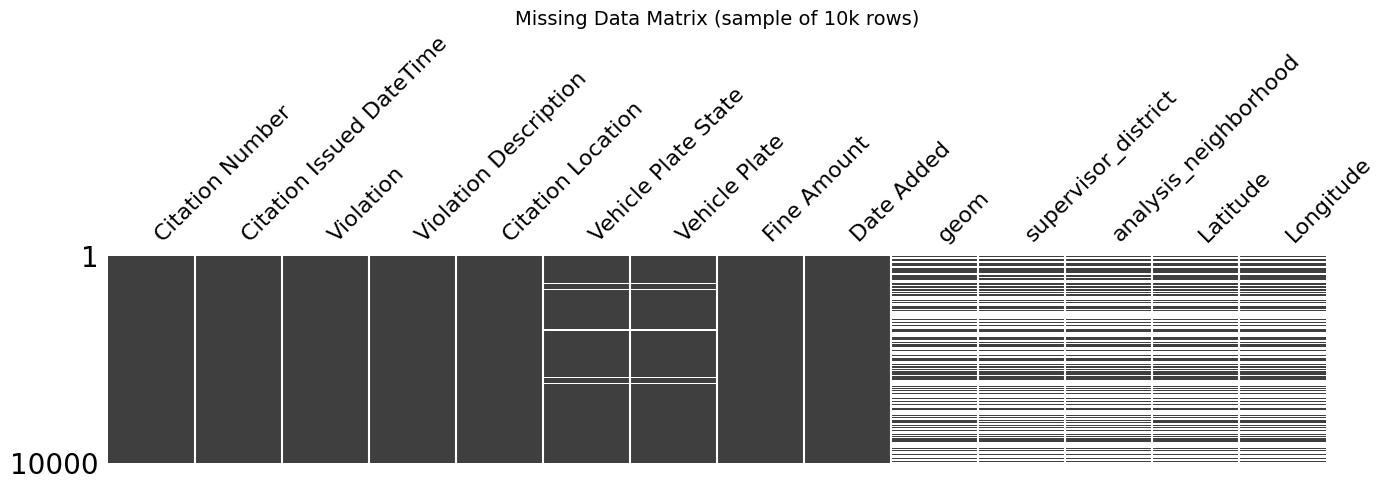

In [9]:
# Visual matrix of missing data
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df.sample(min(10_000, len(df)), random_state=42), ax=ax, sparkline=False)
ax.set_title('Missing Data Matrix (sample of 10k rows)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Data Cleaning


In [10]:
# ── Parse coordinates from geom column ───────────────────────────────────────
df[['LON_parsed', 'LAT_parsed']] = (
    df['geom']
    .str.extract(r'POINT \(([^\s]+) ([^\s]+)\)')
    .astype(float)
)
LAT_COL = 'LAT_parsed'
LON_COL = 'LON_parsed'

# ── Build geo subset: only rows with valid SF coordinates ─────────────────────
df_geo = df.dropna(subset=[LAT_COL, LON_COL]).copy()
df_geo = df_geo[
    df_geo[LAT_COL].between(37.6, 37.9) &
    df_geo[LON_COL].between(-122.6, -122.3)
]

# ── Derive time features (applied to full dataset) ───────────────────────────
df['year']        = df[DATE_COL].dt.year
df['month']       = df[DATE_COL].dt.month
df['day_of_week'] = df[DATE_COL].dt.day_name()
df['hour']        = df[DATE_COL].dt.hour

print('=== Cleaning Summary ===')
print(f'Full dataset (df)              : {len(df):>12,} rows — used for time/violation analysis')
print(f'Geo subset   (df_geo)          : {len(df_geo):>12,} rows — used for map visualizations')
print(f'Dropped (no valid coordinates) : {len(df) - len(df_geo):>12,} rows ({(1 - len(df_geo)/len(df))*100:.1f}%)')
print('✅ Cleaning complete.')

=== Cleaning Summary ===
Full dataset (df)              :   12,303,688 rows — used for time/violation analysis
Geo subset   (df_geo)          :    4,760,091 rows — used for map visualizations
Dropped (no valid coordinates) :    7,543,597 rows (61.3%)
✅ Cleaning complete.


## 6. Exploratory Analysis Tasks

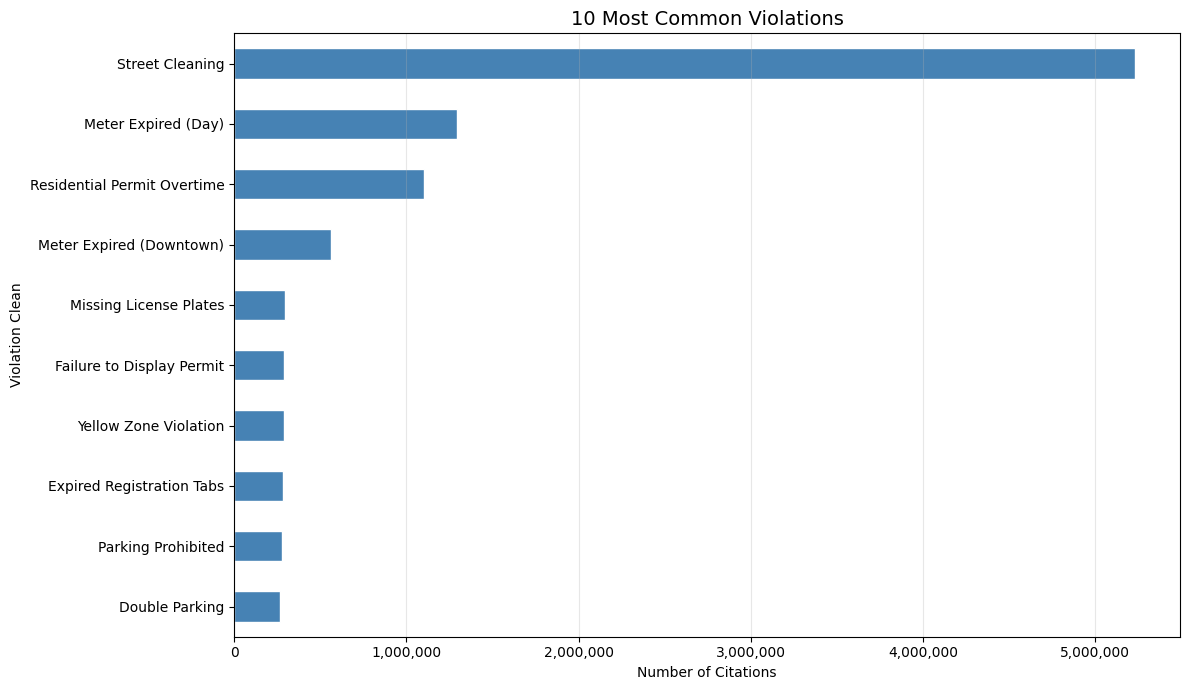


Rank  Violation                              Citations % of Total
-----------------------------------------------------------------
1     Street Cleaning                        5,230,361      42.5%
2     Meter Expired (Day)                    1,294,303      10.5%
3     Residential Permit Overtime            1,104,377       9.0%
4     Meter Expired (Downtown)                 563,936       4.6%
5     Missing License Plates                   294,274       2.4%
6     Failure to Display Permit                292,784       2.4%
7     Yellow Zone Violation                    290,507       2.4%
8     Expired Registration Tabs                286,879       2.3%
9     Parking Prohibited                       276,109       2.2%
10    Double Parking                           264,611       2.2%


In [45]:
# What types of violations are most common (top 10)?

# Plain English mapping for violation codes
violation_map = {
    # Parking Time/Meter
    'STR CLEAN'  : 'Street Cleaning',
    'MTR OUT DT' : 'Meter Expired (Day)',
    'RES/OT'     : 'Residential Permit Overtime',
    'METER DTN'  : 'Meter Expired (Downtown)',
    'PK PHB OTD' : 'Parking Prohibited Overtime',
    'OT OUT DT'  : 'Overtime Outside Downtown',
    'OT PK DT'   : 'Overtime Parking (Day)',
    'OT MTR PK'  : 'Overtime Meter Parking',
    'OVTME PRK'  : 'Overtime Parking',
    'PK OVR 72H' : 'Parked Over 72 Hours',
    'OVER 24 HR' : 'Parked Over 24 Hours',
    'NOPRK 10P6' : 'No Parking 10pm-6am',

    # Registration/Plates
    'NO PLATES'  : 'Missing License Plates',
    'REG TABS'   : 'Expired Registration Tabs',
    'PLT LEF/AT' : 'Plate Left/Attached Improperly',
    'PLATECOVER' : 'License Plate Covered',
    'ALT PLATES' : 'Altered License Plates',
    'PLT F/R'    : 'Plate Front/Rear Missing',
    'FAILRPLPLA' : 'Failure to Replace Plates',
    'NOPL/PRDSP' : 'No Plates or Permit Display',
    'IMP DPL PL' : 'Improperly Displayed Plates',
    'FRD DIS PL' : 'Fraudulent Display of Plates',
    'PL NT PERS' : 'Plate Not Belonging to Person',

    # Permit/Display
    'FAIL DISPL' : 'Failure to Display Permit',
    'FAILTODISP' : 'Failure to Display',
    'FLDISPCLPC' : 'Failure to Display Clipper Card',
    'NO PERMIT'  : 'No Permit',
    'NO PERM'    : 'No Permit',
    'PRMT ONLY'  : 'Permit Parking Only',
    'PRMT PARK'  : 'Permit Parking Violation',
    'PRMT WR CR' : 'Permit Wrong/Incorrect',
    'OBSTR PRMT' : 'Obstructed Permit',
    'PERIOD DIS' : 'Period Display Violation',

    # Zone Violations
    'YEL ZONE'   : 'Yellow Zone Violation',
    'RED ZONE'   : 'Red Zone Violation',
    'WHITE ZONE' : 'White Zone Violation',
    'GREEN ZONE' : 'Green Zone Violation',
    'MAR GRN PK' : 'Market Street Green Zone',
    'BUS ZONE'   : 'Bus Zone Violation',
    'TRK ZONE'   : 'Truck Zone Violation',
    'TRNST ONLY' : 'Transit Only Lane',
    'TRANSIT LN' : 'Transit Lane Violation',
    'SAFE/RED Z' : 'Safety/Red Zone Violation',
    'SAFETY ZN'  : 'Safety Zone Violation',
    'SAFE ZONE'  : 'Safety Zone Violation',
    'HANDI ZONE' : 'Handicap Zone Violation',
    'WHLCHR ACC' : 'Wheelchair Accessible Zone',
    '3 FT WLCHR' : '3 Feet from Wheelchair Ramp',
    'NO PRK ZN'  : 'No Parking Zone',
    'NO PARK'    : 'No Parking',
    'RESTR PRK'  : 'Restricted Parking',
    'RESTRICTED' : 'Restricted Area',
    'TWAWY ZONE' : 'Tow-Away Zone',
    'TWAWY ZN#1' : 'Tow-Away Zone',
    'CM VEH RES' : 'Commercial Vehicle Restricted',
    'RD/WH ZONE' : 'Red/White Zone Violation',
    'B ZN NO DP' : 'Bus Zone No Driveway Parking',
    'B ZN XHTCH' : 'Bus Zone Cross-Hatch',
    'BL ZNE BLK' : 'Blue Zone Blocked',
    'CNSTR TEMP' : 'Construction Temporary Zone',
    'CNSTR ZONE' : 'Construction Zone Violation',
    'TMP PK RES' : 'Temporary Parking Restriction',
    'SCH/PUB GD' : 'School/Public Guard Zone',
    'MC PRKING'  : 'Motorcycle Parking Violation',

    # Blocking/Obstruction
    'PRK PROHIB' : 'Parking Prohibited',
    'PKG PROHIB' : 'Parking Prohibited',
    'PROHIB PRK' : 'Prohibited Parking',
    'DBL PARK'   : 'Double Parking',
    'DBL PKG'    : 'Double Parking',
    'COM DBL'    : 'Commercial Double Parking',
    'DRIVEWAY'   : 'Blocking a Driveway',
    'IN DRIVEWA' : 'Parked in Driveway',
    'ON SIDEWLK' : 'Parking on Sidewalk',
    'BLK SDWLK'  : 'Blocking Sidewalk',
    'BLK BIKE L' : 'Blocking Bike Lane',
    'BLK/INTER'  : 'Blocking Intersection',
    'BLK INTER'  : 'Blocking Intersection',
    'OBSTRCT TF' : 'Obstructing Traffic',
    'OBSTRCT TR' : 'Obstructing Traffic',
    'OB TRF N P' : 'Obstructing Traffic No Permit',
    'BLOCKING'   : 'Blocking Traffic',
    'FIRE HYD'   : 'Blocking Fire Hydrant',
    'PK/CROSS'   : 'Parking in Crosswalk',
    'IN CRSSWLK' : 'Parked in Crosswalk',
    '20FT XWALK' : 'Within 20ft of Crosswalk',
    'PED CROSS'  : 'Blocking Pedestrian Crossing',
    'FCL BLK SP' : 'Blocking Accessible Space',
    'FCL ENT/EX' : 'Blocking Entry/Exit',
    'BLK DOOR'   : 'Blocking Doorway',
    'BLK WHEELS' : 'Blocking Wheels',
    'BLKEV ST'   : 'Blocking EV Station',
    'BK CHG BAY' : 'Blocking Charging Bay',
    '15FT FR ST' : 'Within 15ft of Street',
    '100FT OVER' : 'Over 100ft Violation',
    'MED DIVIDE' : 'Parked on Median/Divider',
    'PK INTER'   : 'Parking at Intersection',
    'RR TRACKS'  : 'Parked on Railroad Tracks',
    'BIC PATHS'  : 'Parked on Bicycle Path',
    'TUBE/TUNNL' : 'Parking in Tunnel/Tube',
    'BRIDGE'     : 'Parking on Bridge',
    'FCL OT PK'  : 'Blocking Overtime Parking',

    # Physical Parking Violations
    'PRK GRADE'  : 'Parking on Grade (No Curbing)',
    'ANGLE PARK' : 'Improper Angle Parking',
    'PRK ON RGT' : 'Parking on Wrong Side',
    'WRG WY PKG' : 'Wrong Way Parking',
    'ONEWAY RD'  : 'Wrong Direction on One-Way Road',
    'PK FR LN'   : 'Parking in Fire Lane',
    'OFF ST LST'  : 'Off Street Parking Violation',
    'ON ST LST'  : 'On Street Parking Violation',
    'OFF STREET' : 'Off Street Violation',
    'ON STREET'  : 'On Street Violation',
    'PK STANDS'  : 'Parking Stands Violation',
    'STAY ON RD' : 'Failure to Stay on Road',
    'DRV OFF RD' : 'Driving Off Road',
    'PARK'       : 'Parking Violation',
    'PRK IN SP'  : 'Parked in Space Incorrectly',
    'PARK/VEH X' : 'Parking/Vehicle Crossover',
    'ACC ROADS'  : 'Access Road Violation',

    # Vehicle Type
    'OVR 18 " C' : 'Over 18 Inches from Curb',
    'OVR 18 \" C': 'Over 18 Inches from Curb',
    'LARGE VEHI' : 'Oversized Vehicle Violation',
    'N/ W/I SPC' : 'Not Within Space',
    'N/WITH SPC' : 'Not Within Space',
    'COMM VEH'   : 'Commercial Vehicle Violation',
    'CM PASSGRS' : 'Commercial Passengers Violation',
    'FOR HIRE'   : 'For Hire Vehicle Violation',
    'LARGE VEHI' : 'Large Vehicle Violation',

    # Fare/Transit
    'UNAUTHFARE' : 'Unauthorized Fare',
    'FARE EVASI' : 'Fare Evasion',
    'CNTRFTFARE' : 'Counterfeit Fare',
    'FEVSN CLPC' : 'Fare Evasion Clipper Card',
    'MISUS CLPC' : 'Misuse of Clipper Card',
    'UNAUT CLPC' : 'Unauthorized Clipper Card',
    'ILL CLPC'   : 'Illegal Clipper Card Use',
    'MISUS TRFR' : 'Misuse of Transfer',
    'MTA NONPAY' : 'MTA Non-Payment',
    'FACIL CRG'  : 'Facility Charge Violation',
    'P U C PEMT' : 'PUC Permit Violation',
    'SGTSEE BUS' : 'Sightseeing Bus Violation',
    'STR CAR'    : 'Streetcar Violation',
    'CBL CAR TR' : 'Cable Car Track Violation',

    # Registration/EV
    'NO EV REG'  : 'No EV Registration',
    'CHGEV S'    : 'EV Charging Station Violation',
    'INVALD PMT' : 'Invalid Payment',

    # Abandoned/Unattended
    'ABAND. VEH' : 'Abandoned Vehicle',
    'ABANDON VH' : 'Abandoned Vehicle',
    'ABND VEH'   : 'Abandoned Vehicle',
    'UNAUTHFARE' : 'Unauthorized Fare',
    'UNATEND VH' : 'Unattended Vehicle',
    'UNATEDN VH' : 'Unattended Vehicle',

    # Miscellaneous
    'DISOB SIGN' : 'Disobeying Sign',
    'SIGNS'      : 'Sign Violation',
    'ENG IDLING' : 'Engine Idling',
    'CAR ALM/EM' : 'Car Alarm Emergency',
    'CAR ALM 15' : 'Car Alarm Over 15 Minutes',
    'ALM TME 15' : 'Alarm Over 15 Minutes',
    'SMOKNG ETC' : 'Smoking Violation',
    'SPITTING'   : 'Spitting Violation',
    'DISTURBAN'  : 'Disturbance',
    'YOUTHMSCON' : 'Youth Misconduct',
    'SOUNDEQUIP' : 'Sound Equipment Violation',
    'FOR SALE'   : 'Vehicle for Sale on Street',
    'WRK ON CAR' : 'Working on Car on Street',
    'RPRING VEH' : 'Repairing Vehicle on Street',
    'EXPLS/FLAM' : 'Explosives/Flammables',
    'EXCAVATION' : 'Excavation Violation',
    'AD SIGNS'   : 'Advertising Signs Violation',
    'SELL/PEDDL' : 'Selling/Peddling',
    'CONV W/ OP' : 'Conversation with Operator',
    'LIVESTKLR'  : 'Livestock on Road',
    'PUB PROP'   : 'Public Property Violation',
    'SF HOSP'    : 'SF Hospital Zone Violation',
    'SOCIAL SER' : 'Social Services Vehicle',
    'FR/EVA/YTH' : 'Fare Evasion Youth',
    'FIRETRAIL'  : 'Fire Trail Parking',
    'RMV CHLK'   : 'Removed Chalk Mark',
    'ONSTCARSH'  : 'On Street Car Share',
    'NO STOP BP' : 'No Stopping Bus Pullout',
    'PASS MISC'  : 'Passenger Miscellaneous',
    'V4000A'     : 'Vehicle Code 4000A Violation',
    'V5204'      : 'Vehicle Code 5204 Violation',
    'V26708A'    : 'Vehicle Code 26708A Violation',
    'V4000.4A'   : 'Vehicle Code 4000.4A Violation',
    'V4457'      : 'Vehicle Code 4457 Violation',
    'V25250'     : 'Vehicle Code 25250 Violation',
    'ILG PRK BL' : 'Illegal Parking Blue Zone',
    'ILL PKG'    : 'Illegal Parking',
    'NO VIOL'    : 'No Violation Found',
    'FTA ON DR'  : 'Failure to Appear on DR',
    'EPM DEVICE' : 'Electronic Parking Meter Device',
    'FLMRE PRMT' : 'Flammable Material Permit',
    'LST/ ST DP' : 'Lost Street Display Permit',
    'MISUSE DP'  : 'Misuse of Display Permit',
    'ST CLEANIN' : 'Street Cleaning',
    'PRK MTR #1' : 'Parking Meter Violation',
    'RESIDENTL'  : 'Residential Parking Violation',
    'URIN/DFECT' : 'Urinating/Defecating in Public',
    'SKARBG/ROL' : 'Skateboarding/Rollerblading',
    'PLT REAR'   : 'Plate Rear Missing',
    'CARELSS DR' : 'Careless Driving',
    'CTY HL PER' : 'City Hall Permit Violation',
    'CM VEH RES' : 'Commercial Vehicle Restriction',
    'OBSTR PRMT' : 'Obstructed Permit',
    '7TH AHEARN' : '7th/Ahearn Parking Violation',
    'PRF PRK'    : 'Preferential Parking',
    'WHLCHR ACC' : 'Wheelchair Accessible Violation',
    'PARK'       : 'Parking Violation',
    'IMP DPL PL' : 'Improperly Displayed Plates',
    'TUBE/TUNNL' : 'Tunnel/Tube Parking',
    'REM VEH CO' : 'Remove Vehicle Cover',
    'CARELSS DR' : 'Careless Driving',
    '18 " CURB"' : 'Over 18 Inches from Curb',
    'NOPL/PRDSP' : 'No Plate or Permit Display',
}

# Apply mapping
df['Violation Clean'] = df['Violation Description'].map(violation_map).fillna(df['Violation Description'])
df_geo['Violation Clean'] = df_geo['Violation Description'].map(violation_map).fillna(df_geo['Violation Description'])

# Plot
top_violations = df['Violation Clean'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 7))
top_violations.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('10 Most Common Violations', fontsize=14)
ax.set_xlabel('Number of Citations')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n{"Rank":<5} {"Violation":<35} {"Citations":>12} {"% of Total":>10}')
print('-' * 65)
for rank, (violation, count) in enumerate(top_violations.items(), 1):
    pct = count / len(df) * 100
    print(f'{rank:<5} {violation:<35} {count:>12,} {pct:>9.1f}%')

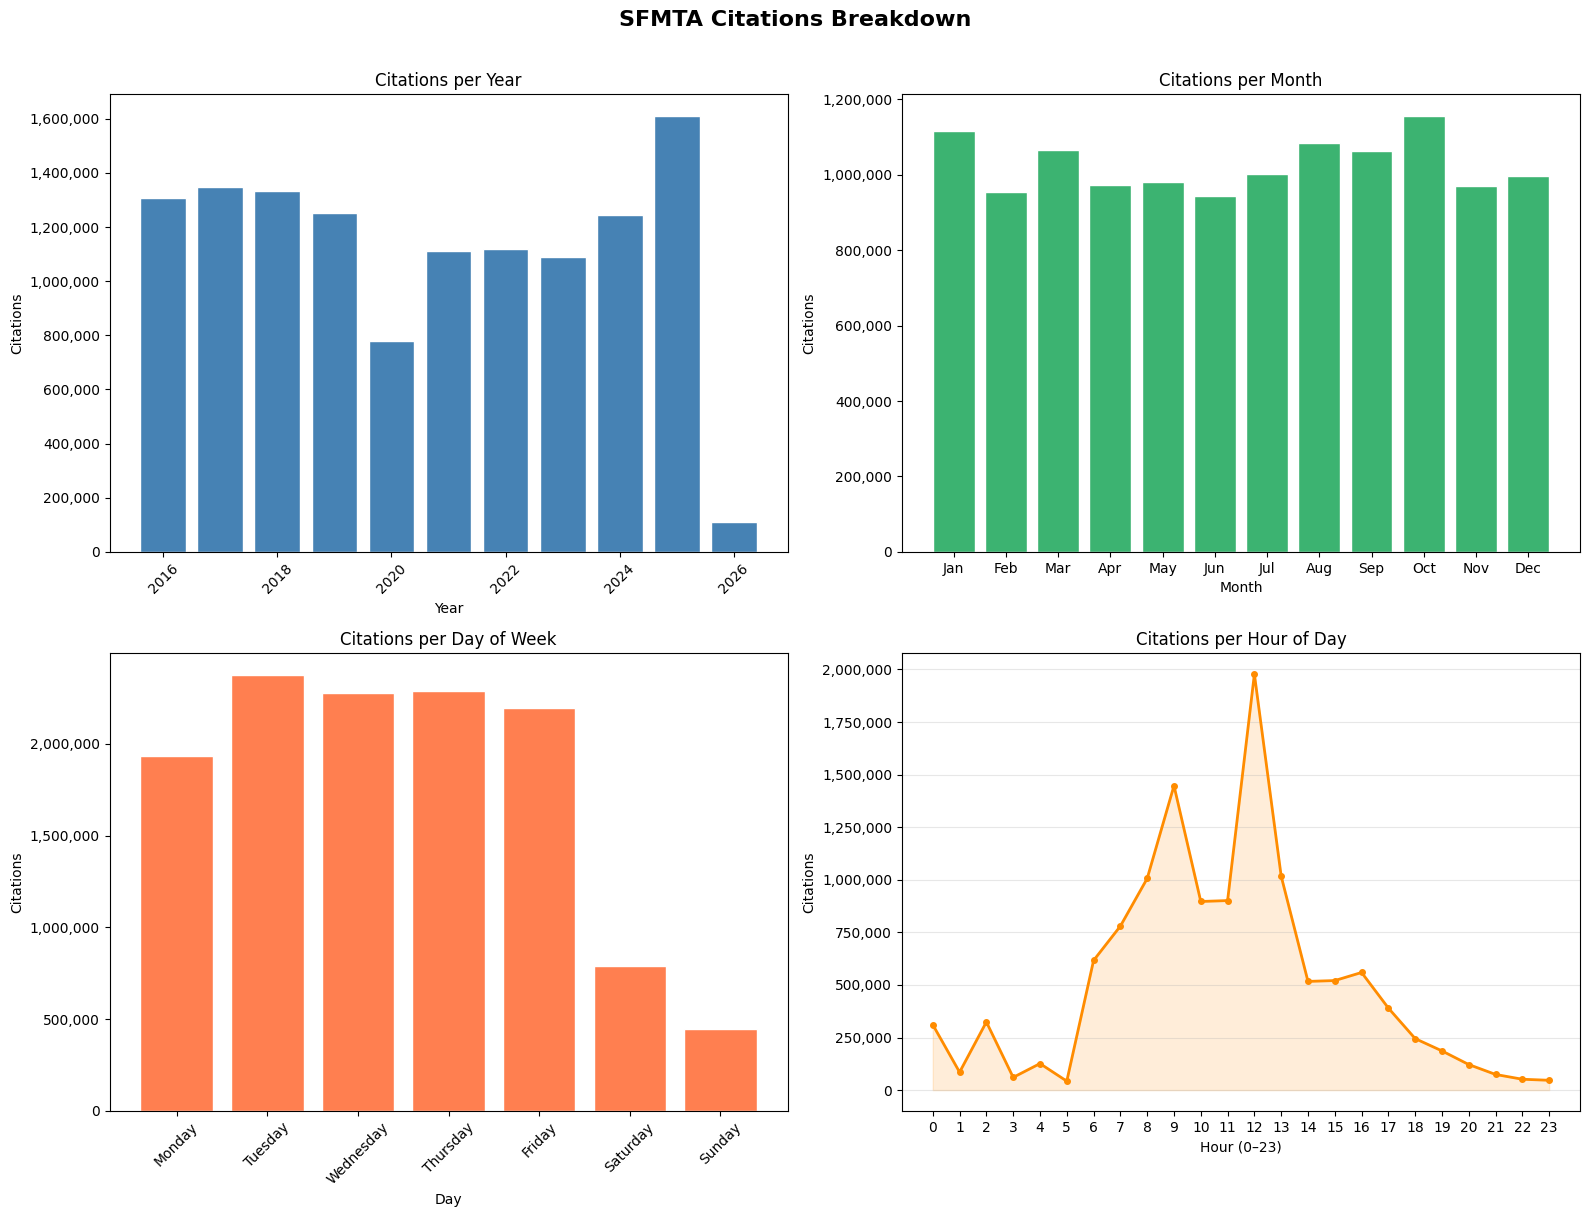

In [24]:
# Tickets per year/month/day of the week/hour

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SFMTA Citations Breakdown', fontsize=16, fontweight='bold', y=1.01)

# Per Year
yearly = df.groupby('year').size()
axes[0,0].bar(yearly.index, yearly.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Citations per Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Citations')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0,0].tick_params(axis='x', rotation=45)

# er Month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month').size()
axes[0,1].bar(month_names, monthly.values, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Citations per Month')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Citations')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Per Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df['day_of_week'].value_counts().reindex(dow_order)
axes[1,0].bar(dow.index, dow.values, color='coral', edgecolor='white')
axes[1,0].set_title('Citations per Day of Week')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Citations')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1,0].tick_params(axis='x', rotation=45)

# Per Hour
hourly = df.groupby('hour').size()
axes[1,1].plot(hourly.index, hourly.values, color='darkorange', linewidth=2, marker='o', markersize=4)
axes[1,1].fill_between(hourly.index, hourly.values, alpha=0.15, color='darkorange')
axes[1,1].set_title('Citations per Hour of Day')
axes[1,1].set_xlabel('Hour (0–23)')
axes[1,1].set_ylabel('Citations')
axes[1,1].set_xticks(range(0, 24))
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

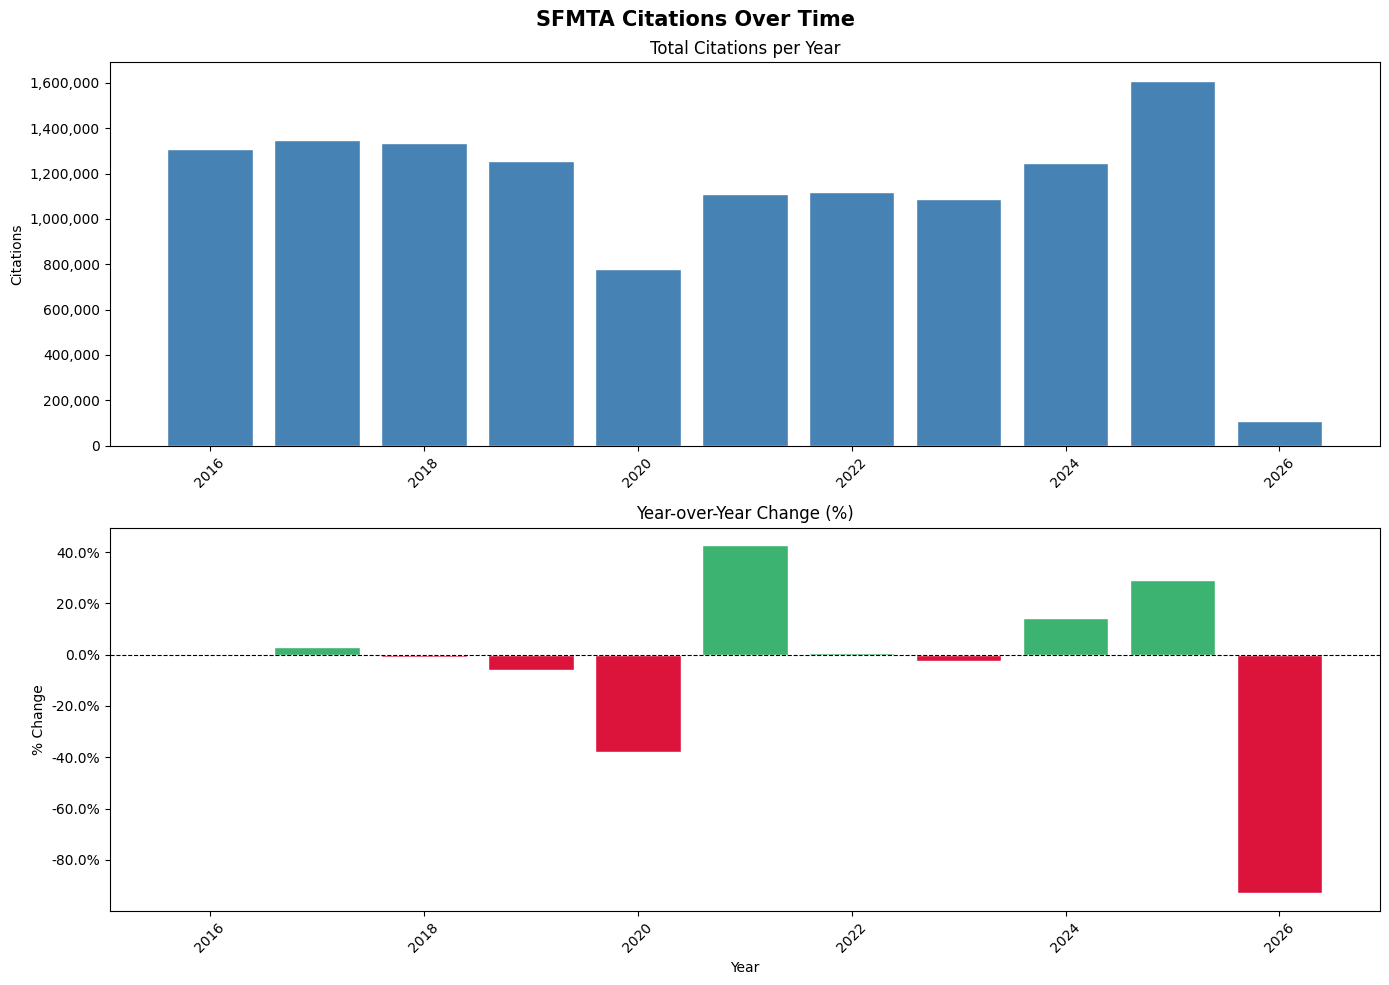


Year      Citations   YoY Change YoY Change (%)
------------------------------------------
2016      1,306,129            —        —
2017      1,346,959      +40,830    +3.1%
2018      1,333,470      -13,489    -1.0%
2019      1,253,615      -79,855    -6.0%
2020        778,183     -475,432   -37.9%
2021      1,111,159     +332,976   +42.8%
2022      1,118,419       +7,260    +0.7%
2023      1,089,411      -29,008    -2.6%
2024      1,246,282     +156,871   +14.4%
2025      1,609,674     +363,392   +29.2%
2026        110,387   -1,499,287   -93.1%

Peak year       : 2025 (1,609,674 citations)
Biggest drop    : 2020 (-37.9%)
Biggest rise    : 2021 (+42.8%)

2026 is excluded from insights because it is a partial year. The data only goes to March


In [25]:
# Analyze and report how the amount of tickets per year changed throughout time

yearly = df.groupby('year').size().reset_index(name='citations')
yearly['yoy_change']  = yearly['citations'].diff()
yearly['yoy_pct']     = yearly['citations'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('SFMTA Citations Over Time', fontsize=15, fontweight='bold')

# Bar chart with trend line
axes[0].bar(yearly['year'], yearly['citations'], color='steelblue', edgecolor='white')
axes[0].set_title('Total Citations per Year')
axes[0].set_ylabel('Citations')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

# Year-over-year % change
colors = ['crimson' if x < 0 else 'mediumseagreen' for x in yearly['yoy_pct'].fillna(0)]
axes[1].bar(yearly['year'], yearly['yoy_pct'].fillna(0), color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Year-over-Year Change (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Change')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Year":<6} {"Citations":>12} {"YoY Change":>12} {"YoY Change (%)":>8}')
print('-' * 42)
for _, row in yearly.iterrows():
    yoy_raw = f"{int(row['yoy_change']):>+,}" if pd.notna(row['yoy_change']) else '      —'
    yoy_pct = f"{row['yoy_pct']:>+.1f}%"      if pd.notna(row['yoy_pct'])    else '      —'
    print(f"{int(row['year']):<6} {int(row['citations']):>12,} {yoy_raw:>12} {yoy_pct:>8}")

# Key insights (exclude 2026 since it's a partial year)
yearly_full = yearly[yearly['year'] < 2026]

peak_year  = yearly_full.loc[yearly_full['citations'].idxmax(), 'year']
peak_count = yearly_full['citations'].max()
drop_year  = yearly_full.loc[yearly_full['yoy_pct'].idxmin(), 'year']
drop_pct   = yearly_full['yoy_pct'].min()
rise_year  = yearly_full.loc[yearly_full['yoy_pct'].idxmax(), 'year']
rise_pct   = yearly_full['yoy_pct'].max()

print(f'\nPeak year       : {int(peak_year)} ({int(peak_count):,} citations)')
print(f'Biggest drop    : {int(drop_year)} ({drop_pct:+.1f}%)')
print(f'Biggest rise    : {int(rise_year)} ({rise_pct:+.1f}%)')
print(f'\n2026 is excluded from insights because it is a partial year. The data only goes to March')

In [100]:
# For each top 10 violation, find its most cited location

top_10_violations = df_geo['Violation Clean'].value_counts().head(10).index.tolist()
df_top10 = df_geo[df_geo['Violation Clean'].isin(top_10_violations)]

# Heatmap
SAMPLE_SIZE = 100_000
geo_sample  = df_top10.sample(min(SAMPLE_SIZE, len(df_top10)), random_state=42)
heat_data   = geo_sample[['LAT_parsed', 'LON_parsed']].dropna().values.tolist()

SF_CENTER    = [37.7749, -122.4194]
location_map = folium.Map(location=SF_CENTER, zoom_start=14, tiles='OpenStreetMap')

HeatMap(
    heat_data,
    radius=25,
    blur=25,
    min_opacity=0.05,
    gradient={
        0.0: '#0000ff',
        0.2: '#00ffff',
        0.4: '#00ff00',
        0.6: '#ffff00',
        0.8: '#ff8000',
        1.0: '#ff0000',
    }
).add_to(location_map)
location_map.save('sfmta_top10_violations_map.html')

# For each top 10 violation, find its most cited location
print(f'\n{"Rank":<5} {"Violation":<35} {"Top Location":<30} {"Citations":>10}')
print('-' * 85)
for rank, violation in enumerate(top_10_violations, 1):
    df_viol = df_top10[df_top10['Violation Clean'] == violation]
    top_loc = df_viol['Citation Location'].value_counts()
    if len(top_loc) > 0:
        print(f'{rank:<5} {violation:<35} {top_loc.idxmax():<30} {top_loc.max():>10,}')

location_map


Rank  Violation                           Top Location                    Citations
-------------------------------------------------------------------------------------
1     Street Cleaning                     814 MISSION ST                        432
2     Meter Expired (Day)                 1737 MONTGOMERY ST                    273
3     Residential Permit Overtime         720 YORK ST                           838
4     Meter Expired (Downtown)            44 BLUXOME ST                         464
5     Expired Registration Tabs           780 MARKET                            152
6     Failure to Display Permit           MISSION                             7,139
7     Parking Prohibited                  55 09TH ST                            690
8     Double Parking                      888 BRANNAN ST                        177
9     Parking on Grade (No Curbing)       1845 FILLMORE ST                      289
10    Yellow Zone Violation               232 BEACH ST                   

## This is my attempt at trying to figure out the daily path that citation workers take

In [105]:
print(df_geo['analysis_neighborhood'].value_counts().to_string())

9592556                   Sunset/Parkside
9592555                       Mission Bay
9592552                   South of Market
9592553                        Tenderloin
9592550    Financial District/South Beach
                        ...              
9587072                            Marina
9587071                            Marina
9587070                          Presidio
9587069                        Tenderloin
9587068                       North Beach
Name: analysis_neighborhood, Length: 5273, dtype: str

In [ ]:
# Show citation movement through the day in Financial District

df_focused = df_day[
    (df_day['analysis_neighborhood'] == 'Financial District/South Beach')
].copy().sort_values('Citation Issued DateTime')

SF_CENTER = [37.7749, -122.4194]
route_map = folium.Map(location=SF_CENTER, zoom_start=14, tiles='OpenStreetMap')

# Color by hour: early=blue, mid=green, late=red
hour_colors = {
    6: '#0000ff', 7: '#0044ff', 8: '#0088ff', 9: '#00ccff',
    10: '#00ffcc', 11: '#00ff88', 12: '#00ff00',
    13: '#88ff00', 14: '#ccff00', 15: '#ffcc00',
    16: '#ff8800', 17: '#ff4400', 18: '#ff0000'
}

# Draw path line through all citations in time order
points = df_focused[['LAT_parsed', 'LON_parsed']].values.tolist()
folium.PolyLine(points, color='gray', weight=1, opacity=0.4).add_to(route_map)

# Mark each citation colored by hour
for _, row in df_focused.iterrows():
    color = hour_colors.get(row['hour'], 'gray')
    folium.CircleMarker(
        location=[row['LAT_parsed'], row['LON_parsed']],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['Citation Location']}</b><br>"
            f"Time: {row['Citation Issued DateTime']}<br>"
            f"Violation: {row['Violation Clean']}",
            max_width=200
        )
    ).add_to(route_map)

# Legend
legend_html = '''
<div style="position:fixed; bottom:40px; right:40px;
    background:rgba(255,255,255,0.9); padding:14px;
    border-radius:8px; font-family:Arial; font-size:12px; z-index:9999;">
    <b>Citation Time of Day</b><br>
    <span style="color:#0000ff;">&#9632;</span> 6–8am<br>
    <span style="color:#00ffcc;">&#9632;</span> 9–10am<br>
    <span style="color:#00ff00;">&#9632;</span> 11am–12pm<br>
    <span style="color:#ffcc00;">&#9632;</span> 1–3pm<br>
    <span style="color:#ff0000;">&#9632;</span> 4–6pm<br>
</div>
'''
route_map.get_root().html.add_child(folium.Element(legend_html))

route_map.save('sfmta_patrol_routes.html')
print(f'{len(df_focused):,} citations plotted')
print(f'Date: {sample_date}')
route_map

575 citations plotted
Date: 2018-01-17
